# U-shape error characterization of Self-training

In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
%matplotlib inline
from dataclasses import replace
from pathlib import Path
import sys
import numpy as np
import torch
from scipy.special import logit, ndtr
from matplotlib import pyplot as plt
from IPython.display import display, Markdown

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from notebooks.temporal_error_attribution import (
    TemporalExperimentParameters, plot_temporal_experiment, run_temporal_experiment,
)

def population_components(run):
    d = run.error_diagnostics['finite']
    beta, alignment = d['normalized_bias'], d['normalized_alignment']
    sigma, p = run.data_cfg.scale, run.data_cfg.label_prior
    plus_error = ndtr((-beta - alignment) / sigma)
    minus_error = ndtr((beta - alignment) / sigma)
    error = p * plus_error + (1 - p) * minus_error
    positive_prediction_rate = p * (1 - plus_error) + (1 - p) * minus_error
    return error, plus_error, minus_error, positive_prediction_rate


def polish_attribution(result, run):
    labels = {
        'alignment_regret': r'$D_{\mathrm{align},t}$',
        'bias_regret': r'$D_{\mathrm{bias},t}$',
        'alignment_regret_increment': r'$\Delta D_{\mathrm{align},t}$',
        'bias_regret_increment': r'$\Delta D_{\mathrm{bias},t}$',
    }
    for ax in result.figures['attribution'].axes:
        legend = ax.get_legend()
        if legend is not None:
            for text in legend.get_texts():
                text.set_text(labels.get(text.get_text(), text.get_text()))

    # Plot the direct population error even where positive-alignment regrets are undefined.
    ax = result.figures['attribution'].axes[0]
    error = population_components(run)[0]
    ax.lines[0].set_ydata(error)
    ax.set_ylim(0, 1)
    ax.set_title('Population error; regrets where defined')


## 1. Experimental setting

Baseline selection thresholds: $\kappa_-=-\mathrm{logit}(0.8)$ and $\kappa_+=\mathrm{logit}(0.8)$.

In [10]:
PARAMETERS = TemporalExperimentParameters(
    name='temporal error-attribution demo',
    seed=49,
    T=100,
    d=3_000,
    delta=8.0,
    rho=0.01,
    label_prior=0.2,
    sigma=1.0,
    signal_std=1.0,
    eta=0.5,
    penalty=0.1,
    pi=2.0,
    kappa=logit(0.8),
    include_bias=True,
    normalized_threshold=False,
    normalize_unlabeled_loss=True
)

In [11]:
baseline_run = run_temporal_experiment(PARAMETERS)
baseline = plot_temporal_experiment(baseline_run, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(baseline, baseline_run)
plt.close('all')

TypeError: make_algorithm_config() got an unexpected keyword argument 'normalize_unlabeled_loss'

## 2. What does the error decomposition measure?

Recall:
$$m_t=\frac{\mu^\top w^t}{d},\qquad \tau_t^2=\frac{\|w^t\|^2}{d},\qquad
\breve b_t=\frac{b^t}{\tau_t},\qquad \breve m_t=\frac{m_t}{\tau_t}.$$
The population risk is given by
$$\mathscr E(\breve b,\breve m)=p\Phi\!\left(\frac{-\breve b-\breve m}{\sigma}\right)+(1-p)\Phi\!\left(\frac{\breve b-\breve m}{\sigma}\right).$$
For positive alignment, the conditionally optimal intercept is
$$\breve b^\star(\breve m)=\frac{\sigma^2}{2\breve m}\log\frac p{1-p}.$$
For negative alignment, the finite stationary point is a maximum. The extended optimal intercept is
$$\breve b^\star(\breve m)=\begin{cases}
-\infty,&\breve m<0,\ p<1/2,\\
+\infty,&\breve m<0,\ p>1/2,\\
\pm\infty,&\breve m<0,\ p=1/2.
\end{cases}$$

- These thresholds mean constant majority prediction, with optimized error $\min(p,1-p)$; no finite bias attains the infimum when alignment is negative.
- At zero alignment, the same rule applies for unequal priors; for $p=1/2$, every bias gives error $1/2$.

The Bayes-optimal linear direction has $\breve m^\star=s_\mu$. One representative is $w^\star=\mu$, $b^\star=(\sigma^2/2)\log[p/(1-p)]$, with $m^\star=s_\mu^2$ and $\tau^\star=s_\mu$. Thus
$$\mathscr E^\star_{\rm lin}=\mathscr E(\breve b^\star(s_\mu),s_\mu).$$

Define the alignment and bias regrets at state $t$ as
$$D_{{\rm align},t}=\mathscr E(\breve b^\star(\breve m_t),\breve m_t)-\mathscr E^\star_{\rm lin},\qquad
D_{{\rm bias},t}=\mathscr E(\breve b_t,\breve m_t)-\mathscr E(\breve b^\star(\breve m_t),\breve m_t),$$
so that $\mathscr E_t=\mathscr E^\star_{\rm lin}+D_{{\rm align},t}+D_{{\rm bias},t}$. Alignment regret is the excess error remaining after optimal bias recalibration; bias regret is the additional cost of the current intercept.

We now define the symmetric coordinate attribution.
Write $E_{ij}^t=\mathscr E(\breve b_{t+i},\breve m_{t+j})$, for $i,j\in\{0,1\}$. Averaging the two coordinate-update orders gives
$$A_t=\tfrac12[(E_{01}^t-E_{00}^t)+(E_{11}^t-E_{10}^t)],\qquad
B_t=\tfrac12[(E_{10}^t-E_{00}^t)+(E_{11}^t-E_{01}^t)],$$
$$\Delta\mathscr E_t:=\mathscr E_{t+1}-\mathscr E_t=A_t+B_t.$$

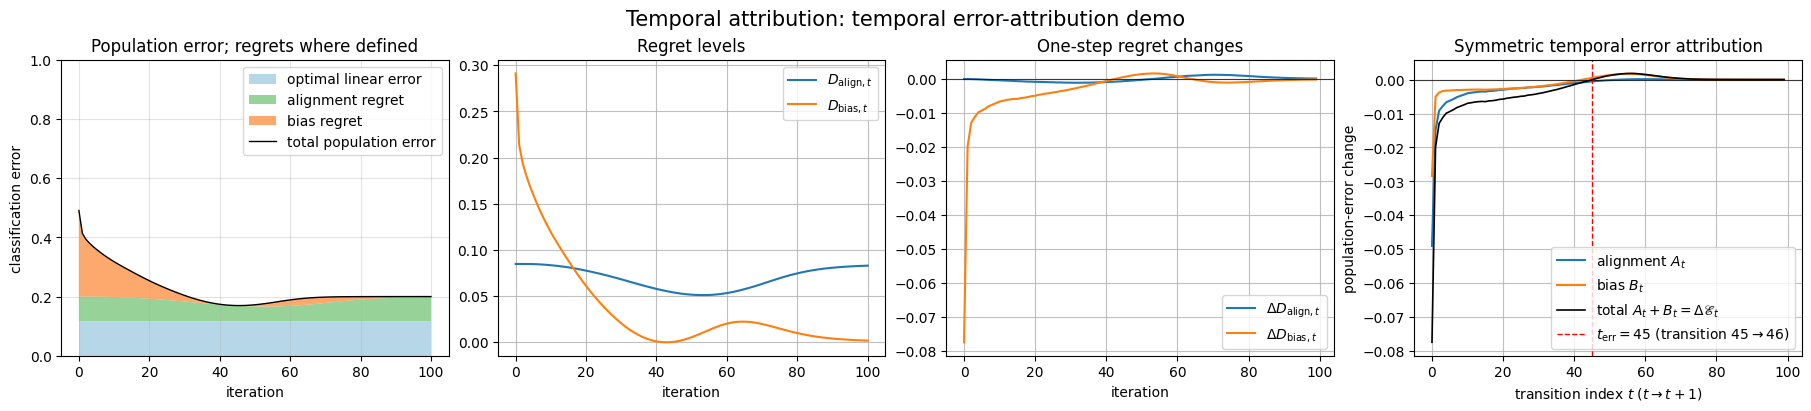

In [ ]:
display(baseline.figures['attribution'])

### Baseline: bias deterioration precedes directional deterioration

We observe three phases:

1. Direction improves and the decision boundary adjusts.
2. Error turns upward: the bias favors the majority class too strongly, outweighing continued alignment improvement.
3. Directional alignment also deteriorates.

- **Interpretation:** a useful direction is insufficient if the decision boundary is poorly calibrated. The optimal bias changes with alignment.
- Lower normalized alignment need not imply lost raw signal: norm growth can outpace signal acquisition.

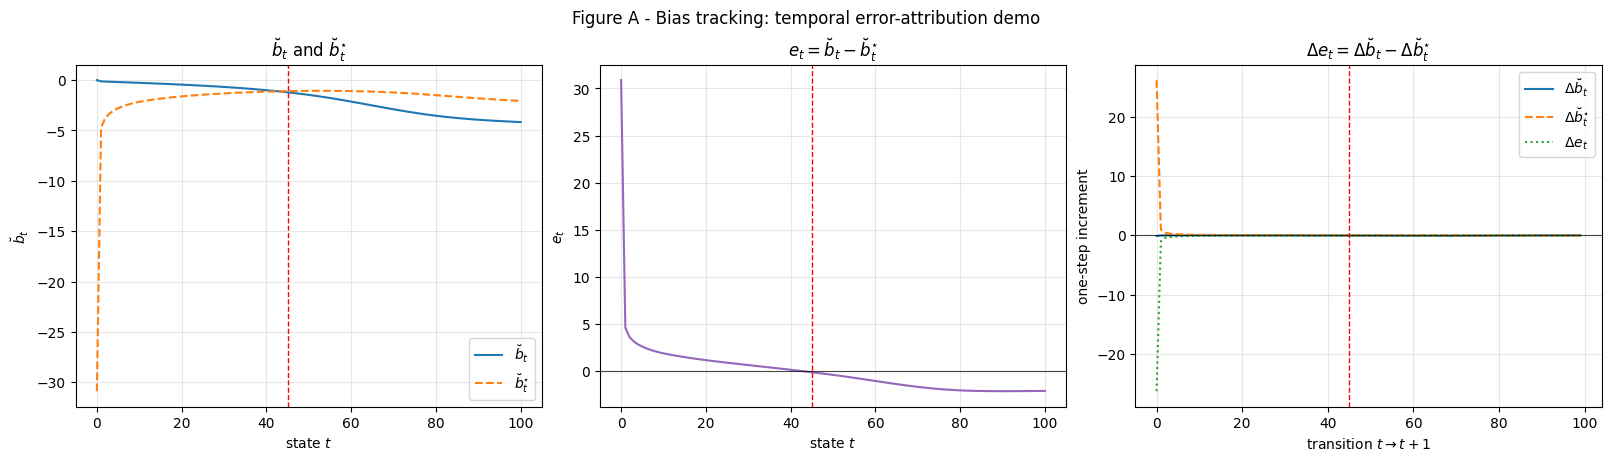

In [ ]:
display(baseline.figures['bias_tracking'])

## 3. Classwise diagnostics

We define the following classwise diagnostics at state $t$, for $y\in\{-1,+1\}$:

1. **Selection rate $\omega_{y,t}$:** fraction selected within true class $y$.
2. **Pseudo-label error $\epsilon_{y,t}$:** fraction mislabeled among selected members of class $y$.
3. **Selected mass $q_{y,t}$:** number of selected members of class $y$, divided by the full sample size.

With $U_y=\{j:\Delta_j=0,Y_j=y\}$ and $C_{y,t}=\{j\in U_y:S_\kappa(r_j^t)=1\}$,
$$\omega_{y,t}=\frac{|C_{y,t}|}{|U_y|},\qquad
\epsilon_{y,t}=\frac{\sum_{j\in C_{y,t}}\mathbf1\{\widehat Y_j^t\ne Y_j\}}{|C_{y,t}|},\qquad
q_{y,t}=\frac{|C_{y,t}|}{n}.$$
Empty denominators give undefined rates.

We see from the below that the minority class is selected less often, with less reliable pseudo-labels. This implies that confidence selection can retain and reinforce confidently wrong predictions.

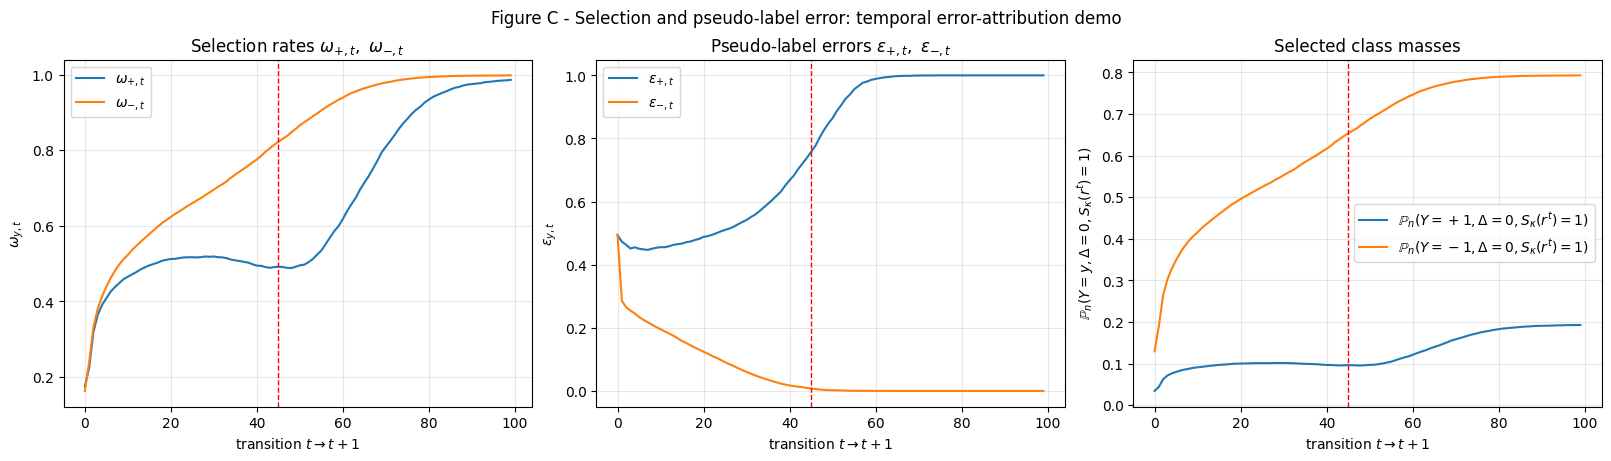

In [ ]:
display(baseline.figures['selection'])

## 4. Asymmetric thresholds

The idea of the following experiments is to admit minority-sign predictions more easily, to counterbalance the class imbalance.
We also consider the reversed threshold configuration, which favors positive predictions and produces a more severe failure than the baseline. Data and initialization are identical, only the thresholds change.

Selection accepts $r\le\kappa_-$ or $r\ge\kappa_+$:

| Rule | $\kappa_-$ | $\kappa_+$ | Easier admission |
|:---|:---|:---|:---|
| Original | $-\operatorname{logit}(0.75)$ | $\operatorname{logit}(0.95)$ | Negative predictions |
| Reversed | $-\operatorname{logit}(0.95)$ | $\operatorname{logit}(0.75)$ | Positive predictions |


In [ ]:
asymmetric_parameters_pos = replace(
    PARAMETERS,
    name='Easier positive admission',
    kappa=None,
    kappa_neg=-logit(0.95),
    kappa_pos=logit(0.75),
)

asymmetric_parameters_neg = replace(
    PARAMETERS,
    name='Easier negative admission',
    kappa=None,
    kappa_neg=-logit(0.75),
    kappa_pos=logit(0.95),
)

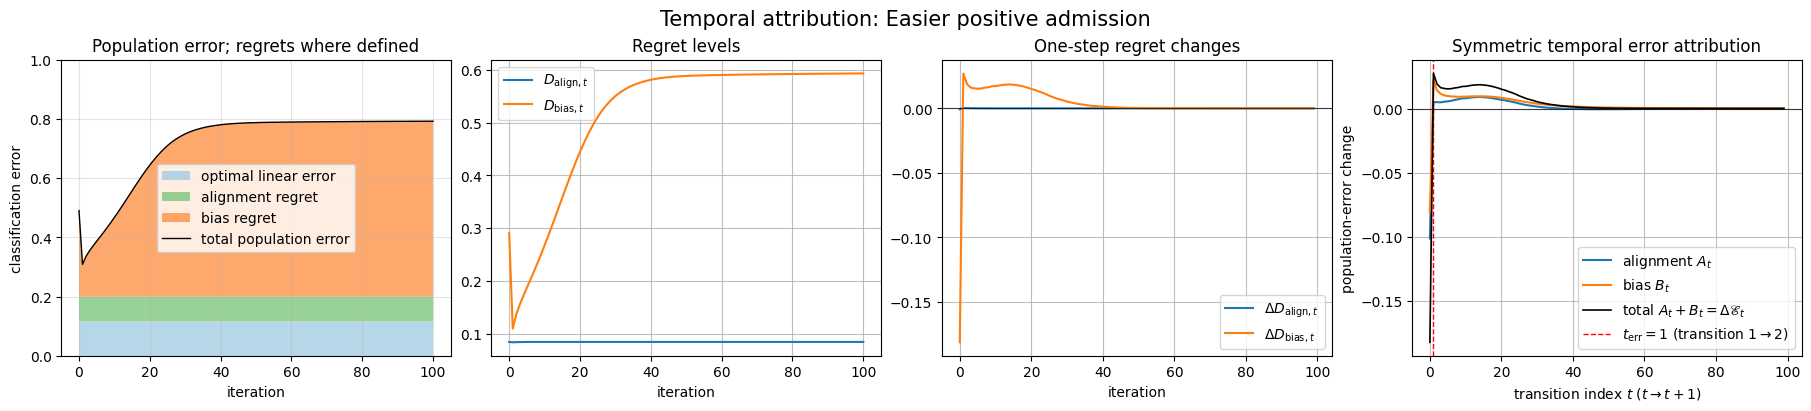

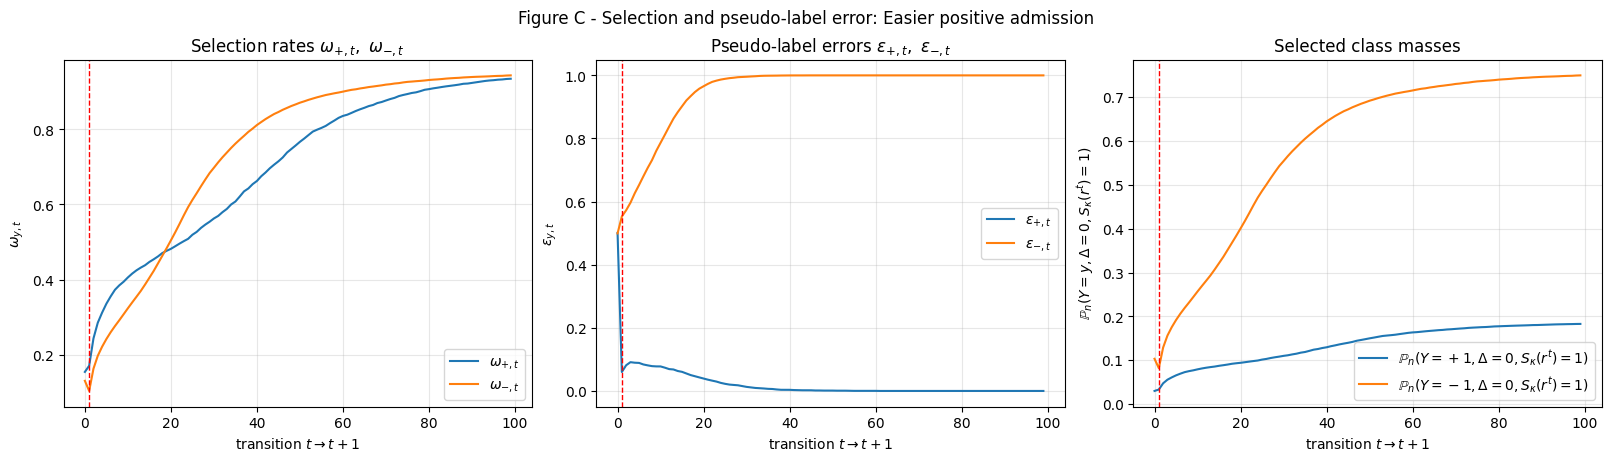

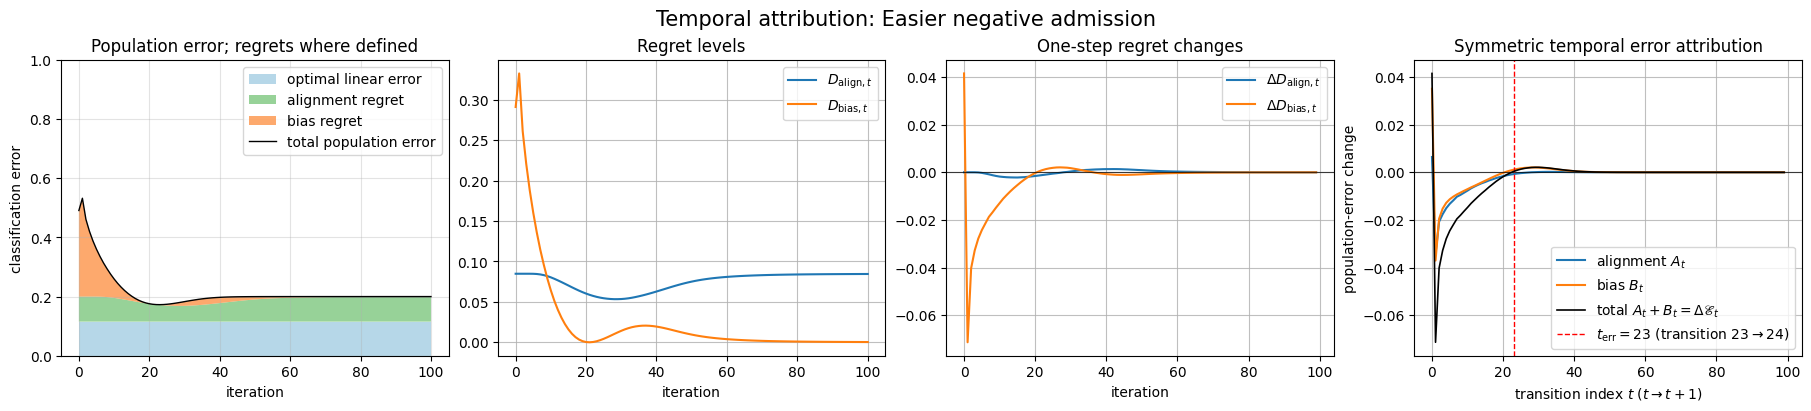

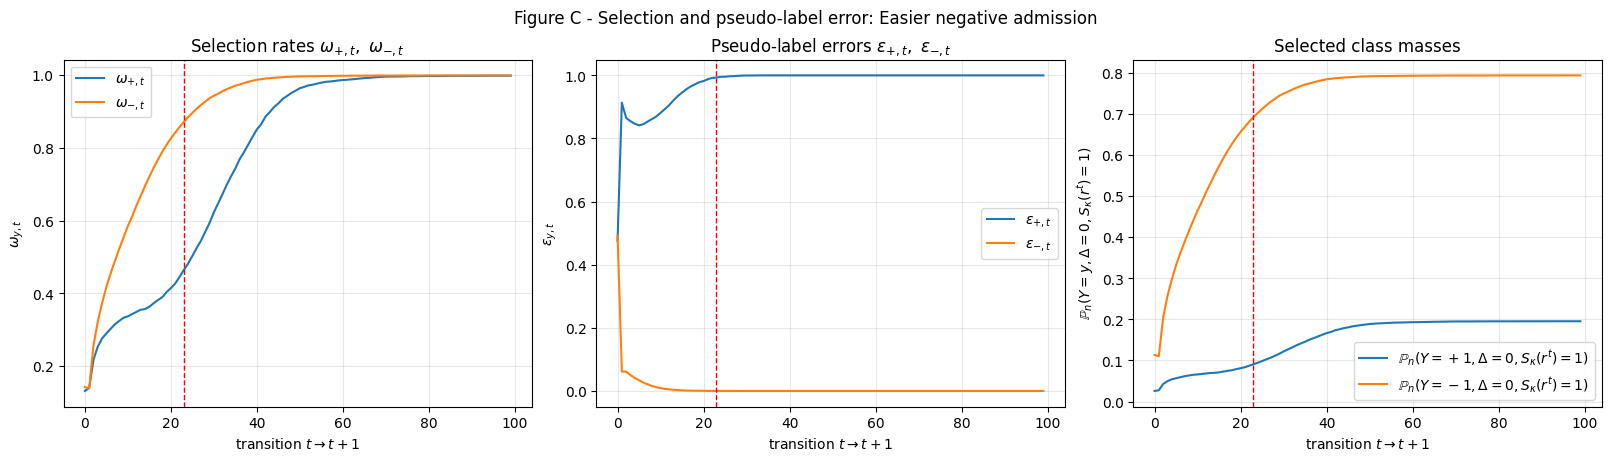

In [ ]:
asymmetric_run_pos = run_temporal_experiment(asymmetric_parameters_pos)
asymmetric_pos = plot_temporal_experiment(asymmetric_run_pos, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(asymmetric_pos, asymmetric_run_pos)
plt.close('all')
display(asymmetric_pos.figures['attribution'])
display(asymmetric_pos.figures['selection'])

asymmetric_run_neg = run_temporal_experiment(asymmetric_parameters_neg)
asymmetric_neg = plot_temporal_experiment(asymmetric_run_neg, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(asymmetric_neg, asymmetric_run_neg)
plt.close('all')
display(asymmetric_neg.figures['attribution'])
display(asymmetric_neg.figures['selection'])

Perhaps counterintuitively, admitting more minority-sign predictions and fewer majority-sign predictions worsens population error.
We see that performance initially improves, but the classifier soon collapses toward constant minority prediction—worse than a coin flip.
The classwise diagnostics show that the rule admits more true minority observations, but also incorrectly assigns the minority label to many majority observations.
Favoring majority-sign predictions instead leads toward constant majority prediction, as in the symmetric case, but accelerates the collapse.

### Comparing the trajectories directly

The experiments show that easier negative admission thresholds leads toward majority prediction, and easier positive admission thresholds leads toward minority prediction. The former is less severe than the latter, but both are worse than the baseline.

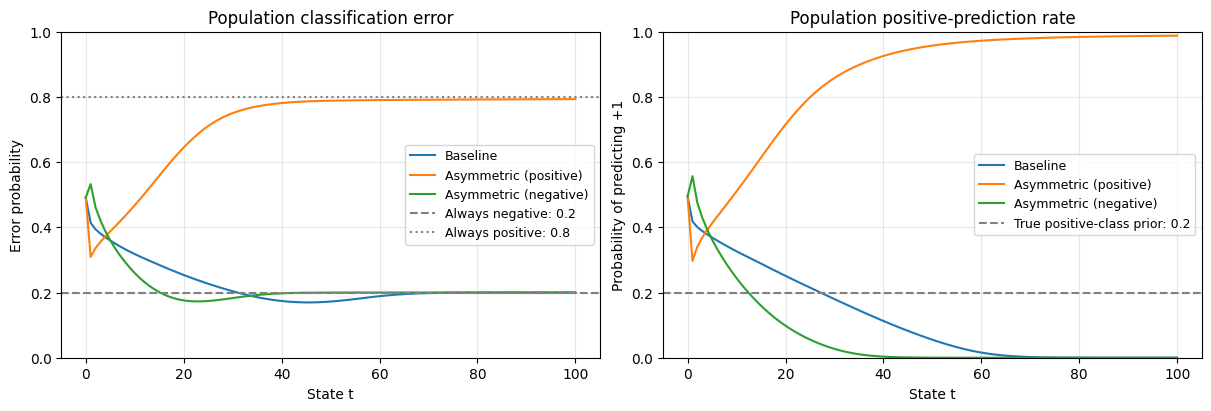

In [ ]:
comparison_runs = [
    ('Baseline', baseline_run),
    ('Asymmetric (positive)', asymmetric_run_pos),
    ('Asymmetric (negative)', asymmetric_run_neg)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for name, run in comparison_runs:
    error, _, _, positive_rate = population_components(run)
    axes[0].plot(error, label=name)
    axes[1].plot(positive_rate, label=name)
axes[0].axhline(0.2, color='gray', linestyle='--', label='Always negative: 0.2')
axes[0].axhline(0.8, color='gray', linestyle=':', label='Always positive: 0.8')
axes[0].set(title='Population classification error', ylabel='Error probability')
axes[1].axhline(0.2, color='gray', linestyle='--', label='True positive-class prior: 0.2')
axes[1].set(title='Population positive-prediction rate', ylabel='Probability of predicting +1')
for ax in axes:
    ax.set(xlabel='State t', ylim=(0, 1))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
plt.show()

From these experiments, we draw the following conclusions:
- The minority-bias asymmetric thresholding succeeds initially, as more selected observations truly belong to the minority.
- The reliability remains poor, and many positive pseudo-labels are actually majority observations.
- The learner reinforces assigned labels, without knowing which are wrong.
- Therefore, better representation alone does not guarantee better discrimination.


## 5. Labeled-only bias updates

We repeat the experiment with bias updates restricted to labeled observations.

In [ ]:
baseline_parameters_lab = replace(
    PARAMETERS,
    name='Baseline (labeled only)',
    bias_pseudo_label_param=0.0,
    eta=2.0,
    T=200
)

asymmetric_parameters_pos_lab = replace(
    asymmetric_parameters_pos,
    name='Easier psotive admission (labeled only)',
    bias_pseudo_label_param=0.0,
    eta=2.0
)

asymmetric_parameters_neg_lab = replace(
    asymmetric_parameters_neg,
    name='Easier negative admission (labeled only)',
    bias_pseudo_label_param=0.0,
    eta=2.0
)

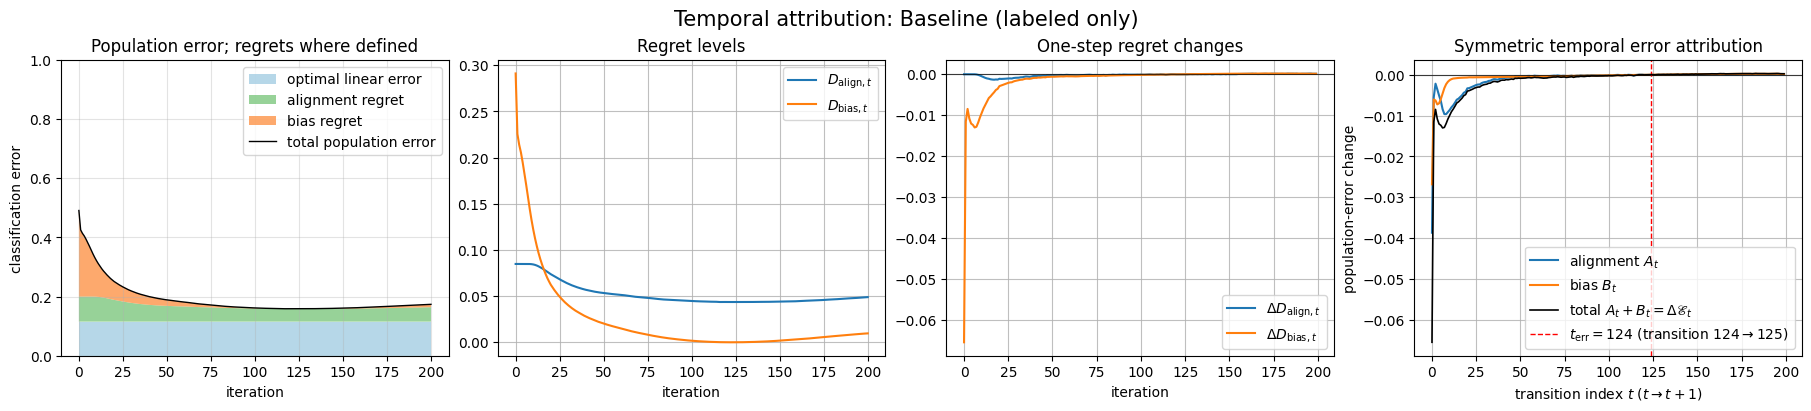

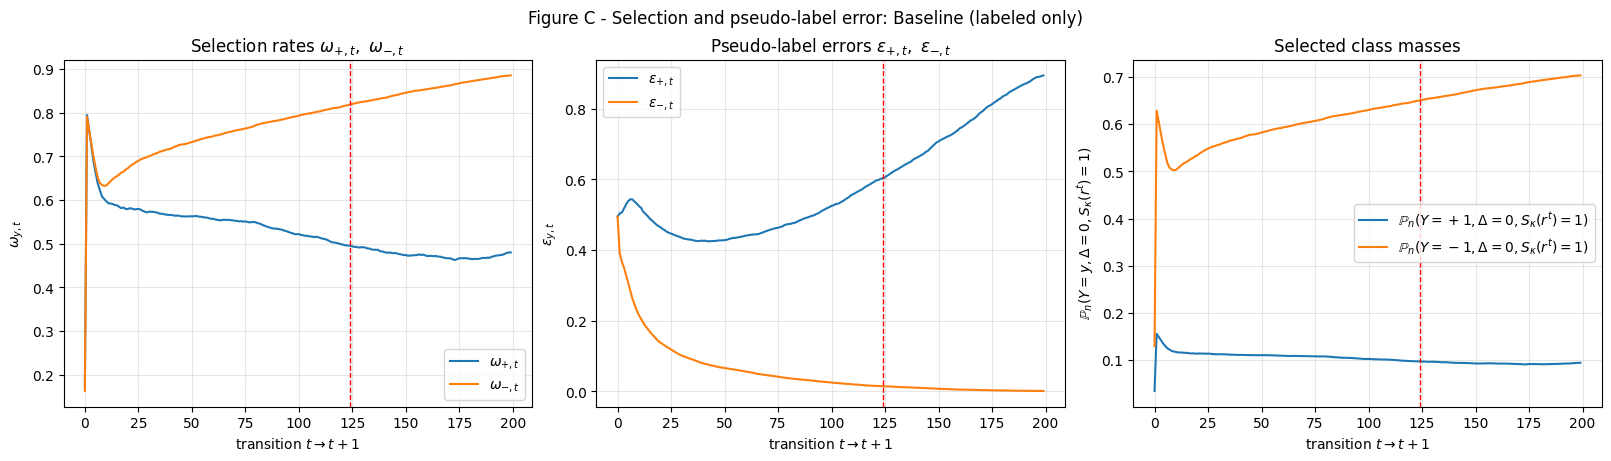

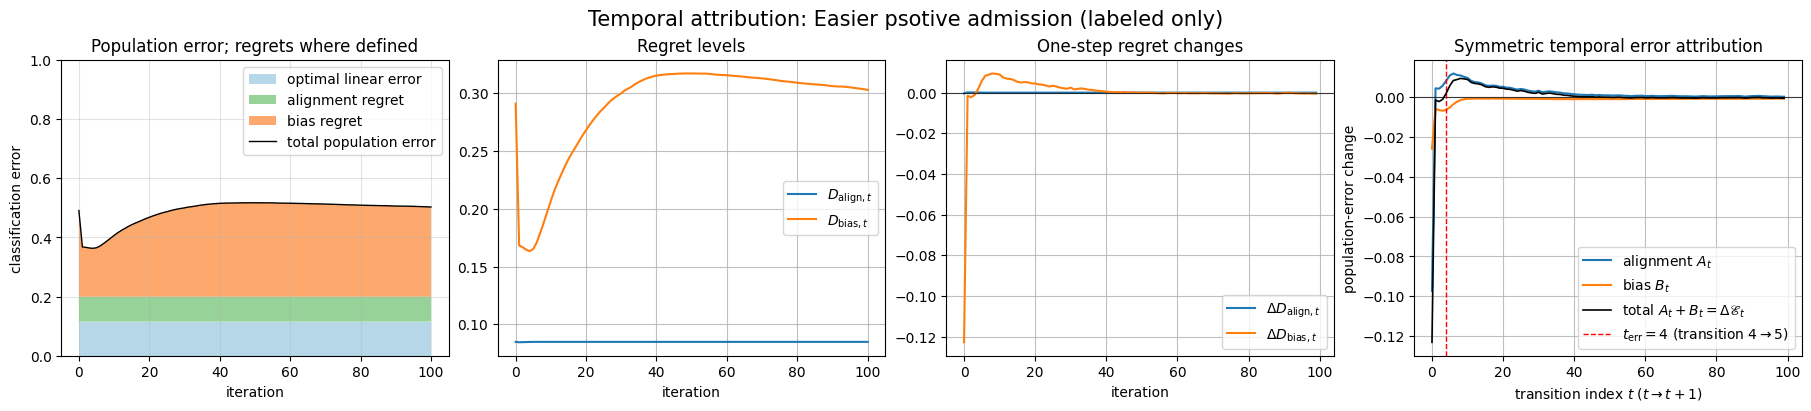

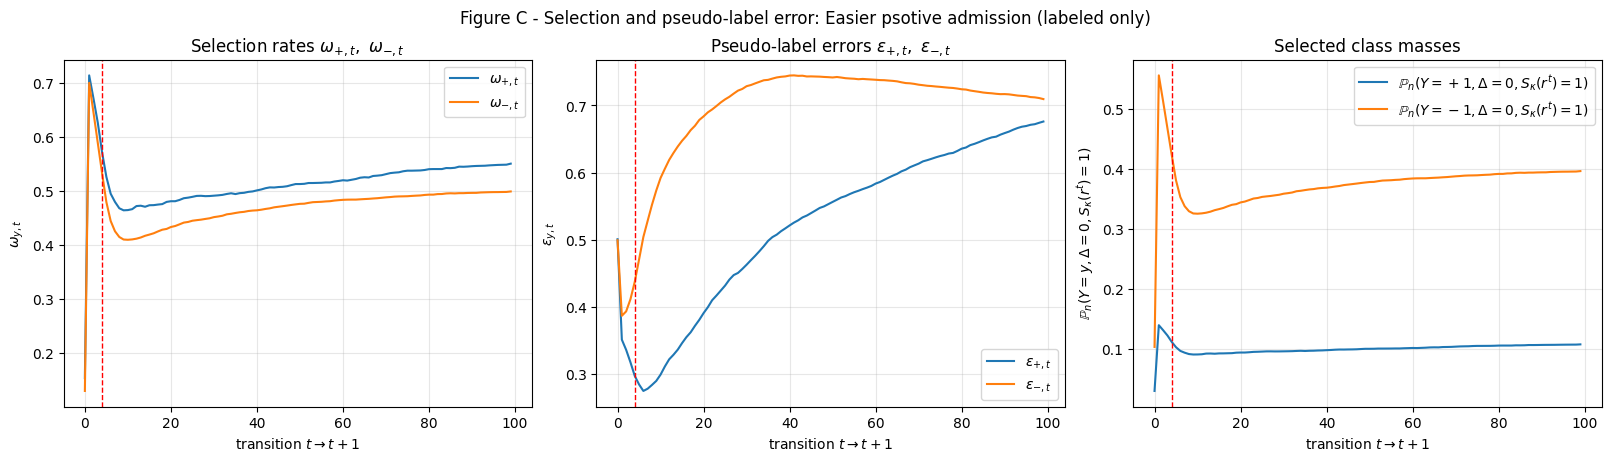

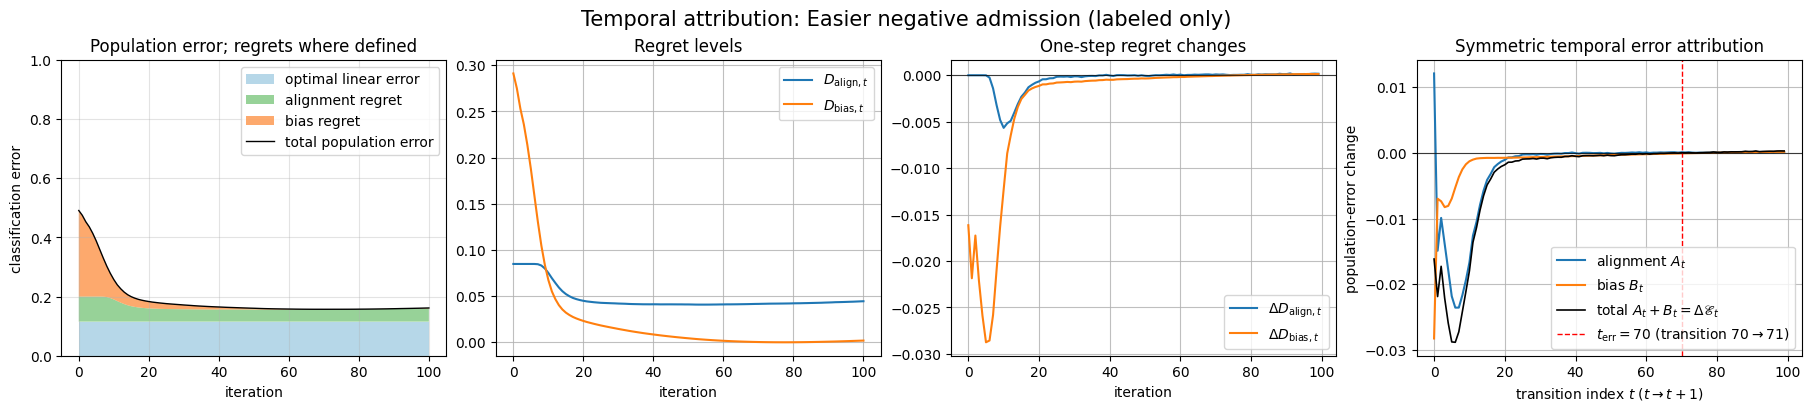

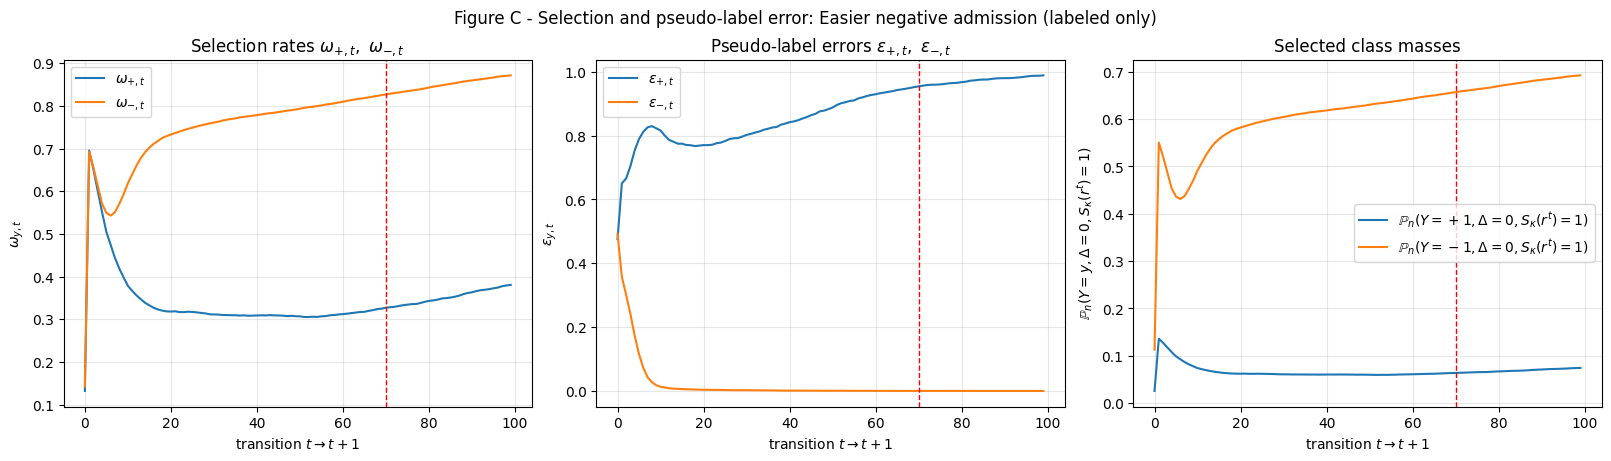

In [ ]:
baseline_lab_run = run_temporal_experiment(baseline_parameters_lab)
baseline_lab = plot_temporal_experiment(baseline_lab_run, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(baseline_lab, baseline_lab_run)
plt.close('all')
display(baseline_lab.figures['attribution'])
display(baseline_lab.figures['selection'])

asymmetric_pos_lab_run = run_temporal_experiment(asymmetric_parameters_pos_lab)
asymmetric_pos_lab = plot_temporal_experiment(asymmetric_pos_lab_run, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(asymmetric_pos_lab, asymmetric_pos_lab_run)
plt.close('all')
display(asymmetric_pos_lab.figures['attribution'])
display(asymmetric_pos_lab.figures['selection'])

asymmetric_neg_lab_run = run_temporal_experiment(asymmetric_parameters_neg_lab)
asymmetric_neg_lab = plot_temporal_experiment(asymmetric_neg_lab_run, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(asymmetric_neg_lab, asymmetric_neg_lab_run)
plt.close('all')
display(asymmetric_neg_lab.figures['attribution'])
display(asymmetric_neg_lab.figures['selection'])

Excluding pseudo-labels from the bias update attenuates the problem, although admitting more positive predictions still worsens performance.
The U-shaped error curve appears to disappear, or becomes less pronounced.
This is likely because pseudo-labels—the source of the harmful feedback—no longer contribute directly to the bias update.

## Normalized Thresholds

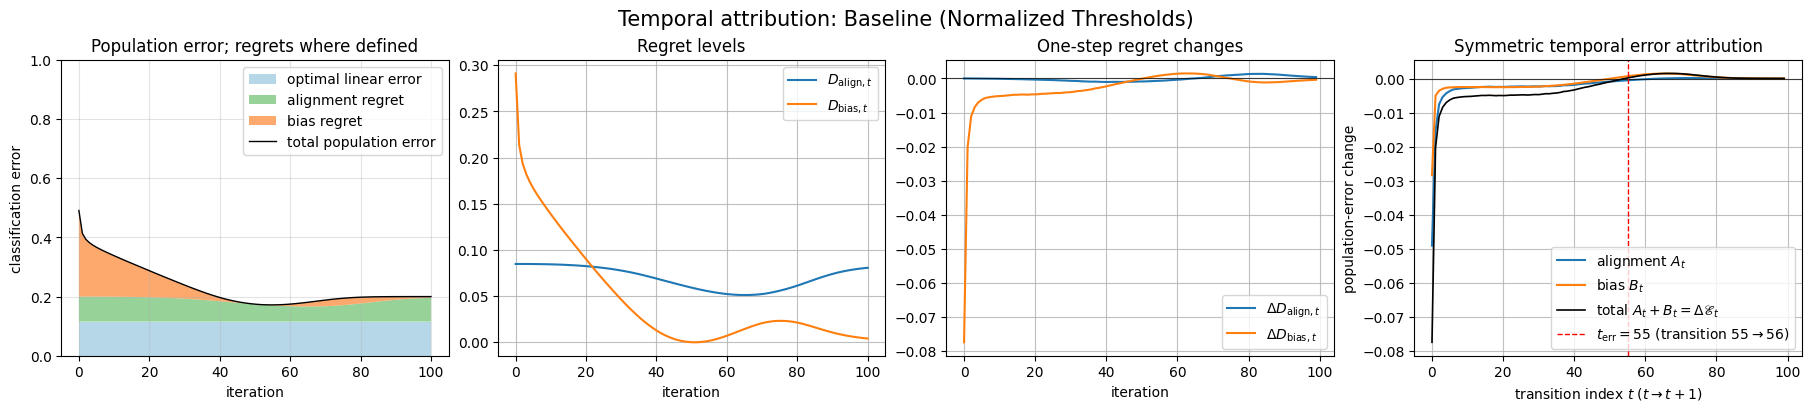

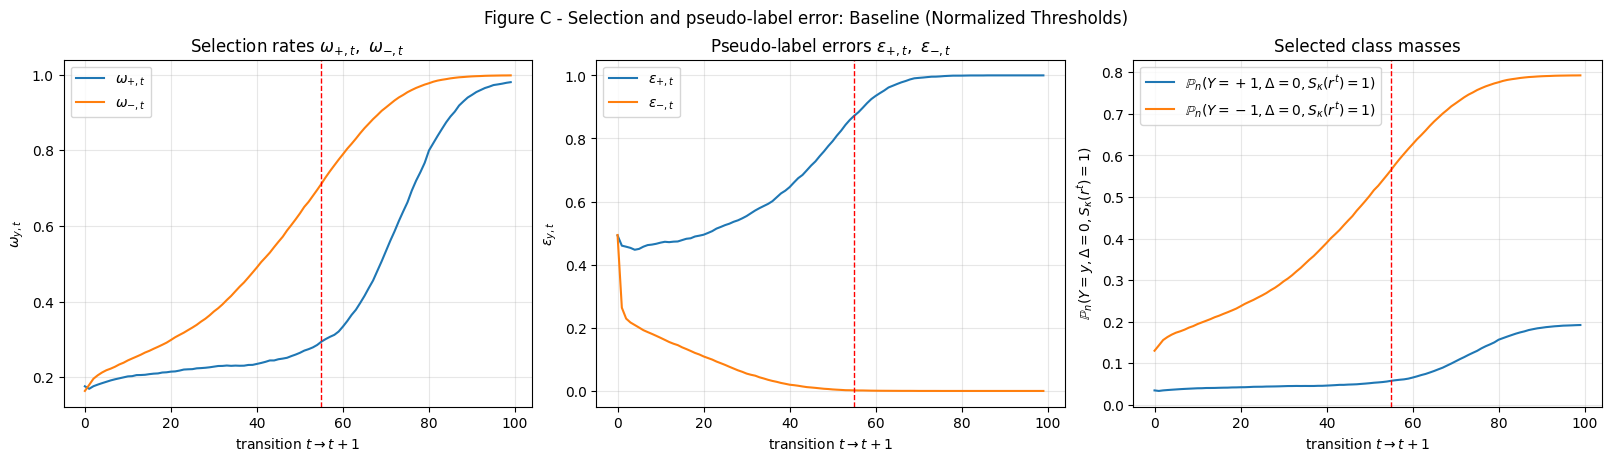

In [ ]:
baseline_parameters_norm = replace(
    PARAMETERS,
    name='Baseline (Normalized Thresholds)',
    normalized_threshold=True
)

baseline_norm_run = run_temporal_experiment(baseline_parameters_norm)
baseline_norm = plot_temporal_experiment(baseline_norm_run, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(baseline_norm, baseline_norm_run)
plt.close('all')
display(baseline_norm.figures['attribution'])
display(baseline_norm.figures['selection'])

## Supervised Only

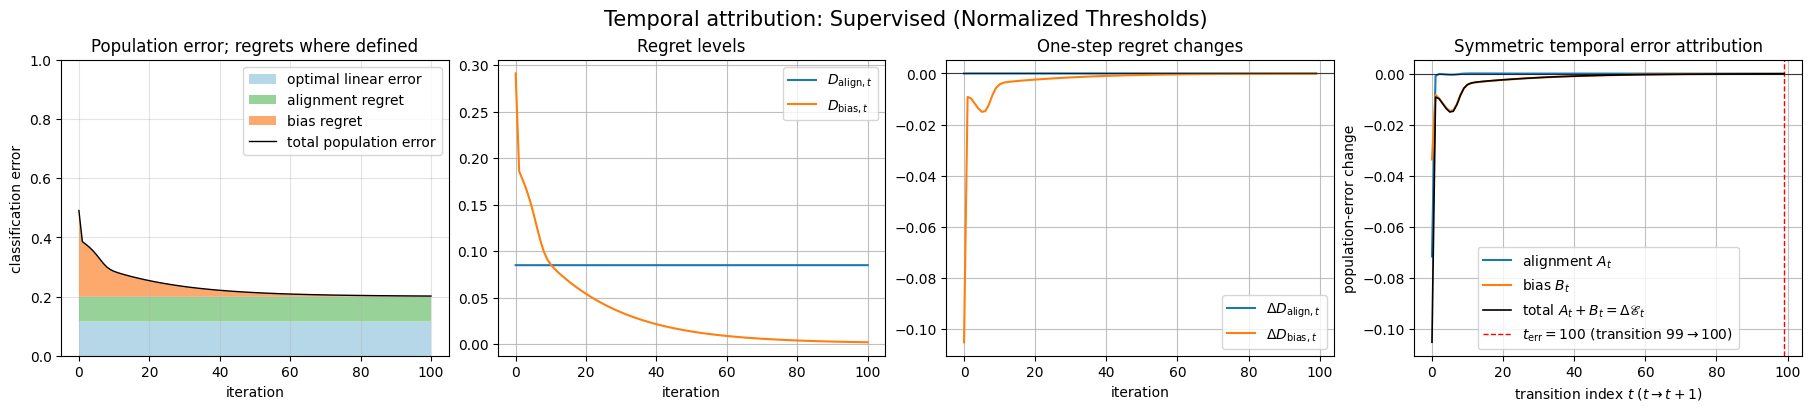

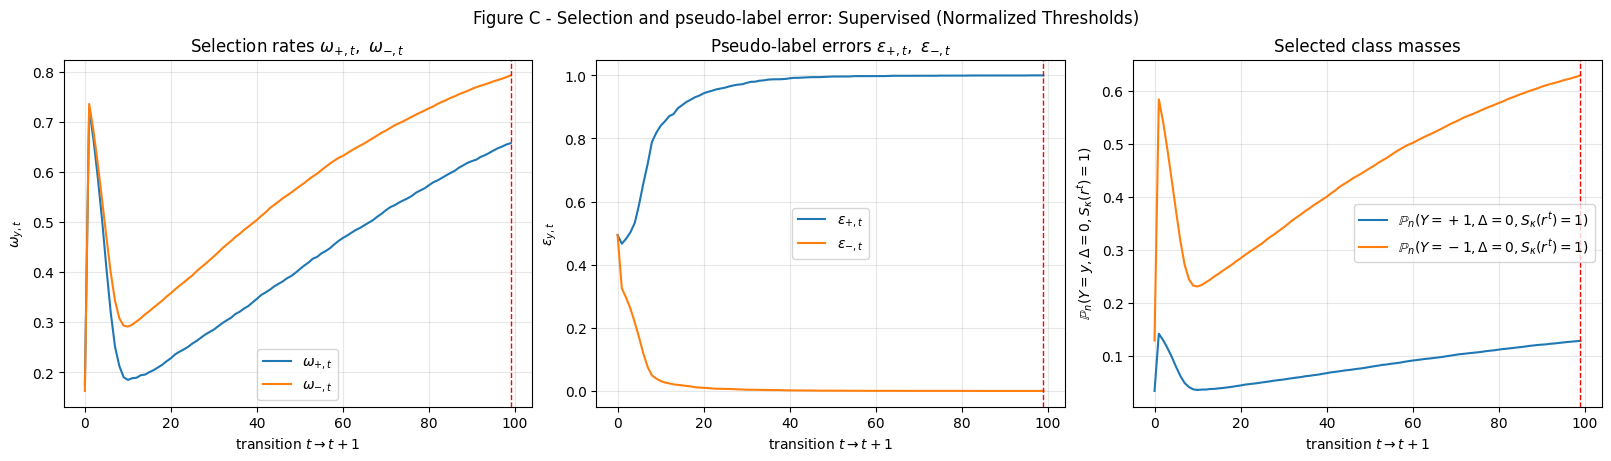

In [ ]:
supervised_parameters = replace(
    PARAMETERS,
    name='Supervised (Normalized Thresholds)',
    pi=0.0,
    eta=2.0
)

supervised_run = run_temporal_experiment(supervised_parameters)
supervised = plot_temporal_experiment(supervised_run, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(supervised, supervised_run)
plt.close('all')
display(supervised.figures['attribution'])
display(supervised.figures['selection'])

## Unnormalized Unlabeled Loss 

In [ ]:
unnormalized_parameters = replace(
    PARAMETERS,
    name='Unnormalized unlabeled loss',
    normalize_unlabeled_loss=False,
)

unnormalized_run = run_temporal_experiment(unnormalized_parameters)
unnormalized = plot_temporal_experiment(unnormalized_run, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(unnormalized, unnormalized_run)
plt.close('all')
display(unnormalized.figures['attribution'])
display(unnormalized.figures['selection'])